# Getting Started

Make sure to follow all instructions in the [Quick Start](../../README.md#quick-start) section before continuing 

### Import all necessary modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time

from scipy.stats import uniform

from smcpy import AdaptiveSampler, VectorMCMC, VectorMCMCKernel
from smcpy.paths import GeometricPath
from smcpy.utils.plotter import *

### Sequential Monte Carlo (SMC) Background Context
**<u>Bayes Theorem</u>**<br />
$$P(\theta | D, M) = \frac{P(D | \theta, M) P(\theta | M)}{\int_{-\infty}^{\infty} P(D | \theta, M) P(\theta | M) d\theta}$$
**<u>Theorem Components</u>**<br />
- $P(\theta | D)$ = Posterior
- $P(D | \theta)$ = Likelihood
- $P(\theta)$ = Prior
- $\int_{-\infty}^{\infty} P(D | \theta) P(\theta) d\theta$ = Marginal Likelihood

**<u>Key</u>**<br />
- $M$ = mathematica model
- $\theta$ = mathematical model parameters
- $D$ = sample


**Prior:** <br />
The assumed distribution of the mathematical model before collecting any samples<br />
**Likelihood:** <br />
Probability of the specific data point occuring given the mathematical model<br />
**Posterior:** <br />
Probability of our mathematical model given our sample<br />
**Marginal Likelihood:** <br />
Normalizing constant to make sure the posterior distribution integrates to 1

The marginal probability component is usually difficult to compute. Therefore we focus on the proportionality,
$$P(\theta | D) \propto P(D | \theta) P(\theta)$$

### What is Sequential Monte Carlo (SMC)?
**<u>Purpose</u>**<br />
SMC is used for solving stochastic inverse problems. The goal of stochastic inverse problems is to determine the parameter distribution based on output data.

**<u>Main SMC Steps</u>**<br />
SMC is broken up to the following main steps:
1. Initialize by taking the number of wanted samples from the prior distribution.
2. Define the **target distribution**.
3. Weight each sample based on the **target distribution**.
4. Resample lower weight samples around higher weight samples
5. Use Markov Chain Monte Carlo (MCMC) to apply a random walk around each sample. 
6. Repeat steps 2 to 5 until the target distribution reaches the posterior distribution (goes through the entirety of the phi sequence).
 
**<u>Target Distribution</u>** <br />
The target distribution, $P_t(\theta | D)$, is represented as,
$$P_t(\theta | D) = P(D | \theta)^{\phi_t} P(\theta)$$
Where $\phi_t$ is part of the increasing phi sequence,
$$[0, \dots, \phi_t, \dots, 1]$$

**<u>Key</u>** <br />
- $\phi_t$ = value between $[0 - 1]$ <br />
- $t = 1, 2, \dots, T$
- $T$ = the total length of the $\phi$ sequence.

Note: <br />
$\phi_t$ = 0 means that the taret distribution directly resembles the prior <br />
$\phi_t$ = 1 means that the target distribution directly resembles our posterior.

# Key Takeaways

From this tutorial we will learn:
- how to create a model function
- how to generate noisy data based on the model we created
- how to run SMC on our generated noisy data to determine our parameter values 

# Example Problem: Linear Model


### Problem Description
To demonstrate the use of SMC, we will fit a linear model to noisy data. The noisy data is represented as: $$y_i = Ax_i + B + \epsilon_i$$ where $y_i$ is a single observation at $x_i$ and $\epsilon_i$ represents independent and identically distributed measurement noise. For the purposes of the demonstration, we'll generate synthetic data by adding zero-mean, normally distributed noise with standard deviation $\sigma=2$ to a known line, defined by $A=2$ and $B=3.5$ across $x_i = [0, 99]$ **(This will be referenced as our <u>"true line"</u> from here on out).**  

The goal will be to learn the posterior probability distribution over $A$ and $B$ conditioned on the available data.

### Creating The Linear Model
We first need to define our model:
$$y_i = Ax_i + B$$
This should take in a single 2D parameter array and return $y$ at each $x_i$ where the noisy data has been observed.

When creating our model, we use numpy vectorization to extract the $A$ and $B$ values from our 2D array and also apply mathematical computations such as multiplication and addition to our array elements. Numpy vectorization allow us to do these tasks much faster in comparison to Python for-loops.


In [2]:
def eval_model(theta):
    time.sleep(0.1)  # artificial slowdown to show off progress bar
    a = theta[:, 0, None]
    b = theta[:, 1, None]
    return a * np.arange(100) + b


Breaking down the `eval_model` function:

We start by using numpy vectorization to collect all the $A$ parameter values by going through all the rows and collecting it from the 0th column. <br />
`a = theta[:, 0, None]`

We now do a similar process but we collect the $B$ parameter values from the 1st column instead. <br />
`b = theta[:, 1, None]`

Lastly we turn the output from a 1d numpy array into a 2d numpy array using `None`. This makes sure our numpy arrays are formatted correctly for element by element multiplication in `a * np.arange(100) + b`.

Ex:
```
theta = 
    [[2 4] 
    [4 5]]
```
Without `None`: 
```
theta[:, 0]
a = [2 4]
```

With `None`:
```
theta[:, 0, None]
a = 
    [[2] 
    [4]]
```

### Generating and Plotting Noisy Data Using the Linear Model


To generate the noisy dataset, we now need to define our identically independant distribution measurement noise, $\epsilon_i$. We will do this by applying a zero-mean, normally distributed noise with standard deviation $\sigma=2$ to the true line. The image below is the data plotted over the true line.

In [3]:
def plot_noisy_data(x, y_true, noisy_data):
    fig, ax = plt.subplots(1)
    ax.plot(x.flatten(), y_true.flatten(), "-k")
    ax.plot(x.flatten(), noisy_data.flatten(), "o")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.show()

In [4]:
def generate_data(eval_model, std_dev, plot=True, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    y_true = eval_model(np.array([[2, 3.5]]))
    noisy_data = y_true + rng.normal(0, std_dev, y_true.shape)
    if plot:
        plot_noisy_data(np.arange(100), y_true, noisy_data)
    return noisy_data

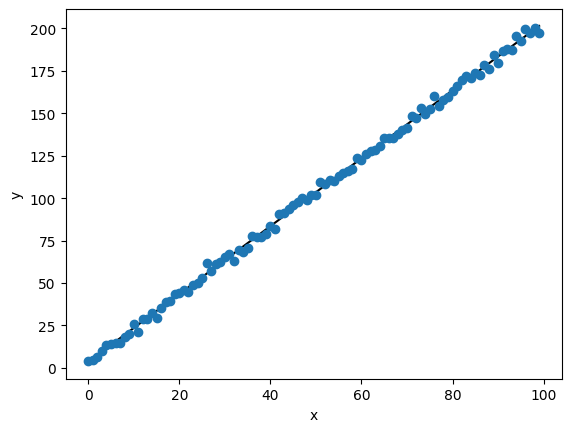

In [5]:
rng = np.random.default_rng(200)
std_dev = 2
noisy_data = generate_data(eval_model, std_dev, plot=True, rng=rng)

Breaking down the `generate_data` function:

We first determine the seed for the numpy random generator.  <br />
`rng = np.random.default_rng() if rng is None else rng`

We then provide the model with the true values of the parameters and store the output values as a numpy array. <br />
`y_true = eval_model(np.array([[2, 3.5]]))` 

Lastly we generate a numpy array with the same size as the output array and generate the data noise using our wanted normal distribution. <br />
`noisy_data = y_true + rng.normal(0, std_dev, y_true.shape)` 

### Providing Prior Distributions
To solve the Bayesian inference problem, we need to define priors over our parameters. In SMCPy, this is done by using scipy to generate our prior distributions. For this problem we will assume that the $A$ and $B$ parameters in the linear model have prior distributions that are uniform distributions when both $A$ and $B$ ranges from $[0, 6]$. 

Note that using a uniform distribution is not required and you are free to provide a prior distribution that best represents your data. 

In [6]:
priors = [uniform(0.0, 6.0), uniform(0.0, 6.0)]

### Setting Up and Running the SMC Sampler

SMCPy has 2 different samplers, a ```Fixed Sampler``` and an ```Adaptive Sampler```.
1. A ```Fixed Sampler``` is a sampler that requires the user to provide a predetermined phi sequence to calculate it's [**target distributions**](#what-is-sequential-monte-carlo-smc). 
2. An ```Adaptive Sampler``` is a sampler that does not require the user to provide a predetermine phi sequence to calculate it's [**target distribution**](#what-is-sequential-monte-carlo-smc). 
$$\phi = [0, ..., ???, 1]$$

For this problem we will be using the ```AdaptiveSampler```, which picks $\phi_t$ values based on a target effective sample size, which we will define as 70% of the particle population. The $\phi_t$ values also depend on the number of particles we want to sample, and the number of MCMC steps we want to take after each resampling. We also define both as 500 and 5 samples respectively. Below we see a progress bar to show when our SMC run has finished. <br />


In [7]:
# require phi=0.2 be included in adaptive sequence
path = GeometricPath(required_phi=0.2)

vector_mcmc = VectorMCMC(eval_model, noisy_data, priors, std_dev)
mcmc_kernel = VectorMCMCKernel(vector_mcmc, ("a", "b"), path=path, rng=rng)
smc = AdaptiveSampler(mcmc_kernel)

step_list, mll_list = smc.sample(
    num_particles=500, num_mcmc_samples=5, target_ess=0.7, progress_bar=True
)

[ mutation ratio: 0.984: : 100.00%|████████████████████████████████████████████████████████████▉| phi: 1.00000/1.0 [00:08<00:00



Breaking Down The Set Up and Run for SMC:

We start by providing the MCMC algorithm with the model, data, priors, and std_dev.<br />
```vector_mcmc = VectorMCMC(eval_model, noisy_data, priors, std_dev)```
 
We then use use the ```VectorMCMCKernel``` to reformat our ```vector_mcmc``` to be usable by SMC. <br />
```mcmc_kernel = VectorMCMCKernel(vector_mcmc, ("a", "b"), path=path, rng=rng)``` 

Now we provide SMC with one of the 2 samplers. For this case we chose to use the ```AdaptiveSampler```. <br />
```smc = AdaptiveSampler(mcmc_kernel)```

Lastly we provide the number of particles, the number of MCMC steps to take place after each resample, and the target effective sample size for SMC.
```
step_list, mll_list = smc.sample(
    num_particles=500, num_mcmc_samples=5, target_ess=0.7, progress_bar=True
)
```

### Displaying SMC Results

Once the sampler has finished running, we can visualize the posterior distribution using a seaborn pairplot. 

As we can see with the scatter plots, each SMC sample is represented as a dot containing a potential $A$ and $B$ value used to create our true line. For the histograms, we see that the majority of the SMC samples are clustered when $A \approx 2$ and when $B \approx 3.5$. This similarly reflects our true values of when $A = 2$ and $B = 3.5$!

phi_sequence=[0.00000000e+00 6.27142981e-06 2.49739087e-05 9.20266282e-05
 3.28302802e-04 1.12055895e-03 3.95329792e-03 1.40597370e-02
 4.47290659e-02 1.10374224e-01 2.00000000e-01 4.50217846e-01
 9.90990032e-01 1.00000000e+00]
fbf norm index=[10]
marginal log likelihood = -227.79426575479616
parameter means = {'a': 2.001946850638628, 'b': 3.3275880709139227}


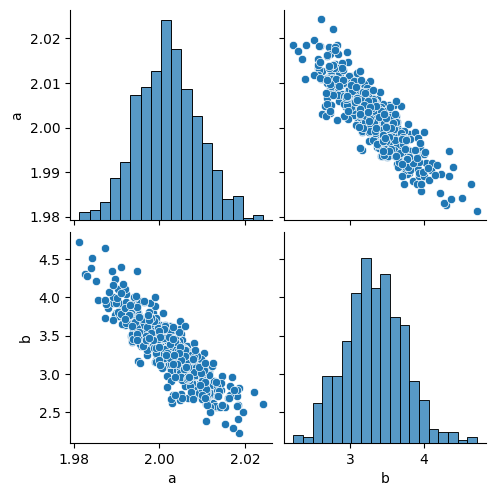

In [8]:
print(f"phi_sequence={smc.phi_sequence}")
print(f"fbf norm index={smc.req_phi_index}")
print("marginal log likelihood = {}".format(mll_list[-1]))
print("parameter means = {}".format(step_list[-1].compute_mean()))

sns.pairplot(pd.DataFrame(step_list[-1].param_dict))
sns.mpl.pyplot.savefig("pairwise.png")